# ResNet-18 Quantisation Sweep — Analysis
Loads all `result.json` files from `../runs` and produces a summary table + four separate plots.

In [1]:
# ── Cell 1: Imports & data loading ──────────────────────────────────────────
import sys
sys.path.insert(0, "../src")  # adjust if needed

import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
from matplotlib.lines import Line2D

warnings.filterwarnings('ignore')
%matplotlib inline
plt.rcParams.update({
    'figure.dpi': 130,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11,
})

from utils import load_runs, flatten_runs

runs = load_runs("../runs", status="ok")
df   = pd.DataFrame(flatten_runs(runs))

# Convenience columns
df['backend']    = df['cfg.backend']
df['precision']  = df['cfg.model_precision']
df['input_bits'] = df['cfg.input_quant_bits'].fillna(0).astype(int)
df['top1']       = df['res.top1_acc']
df['top5']       = df['res.top5_acc']
df['lat_ms']     = df['res.infer_ms_avg']
df['tput']       = df['res.throughput_infer_sps']

# Shared style constants
PRECISION_ORDER = ['fp8', 'fp16', 'fp32', 'int4', 'int8']
INPUT_BITS_LIST = sorted(df['input_bits'].unique())
BACKENDS        = sorted(df['backend'].unique())

BACKEND_COLORS = {
    'pytorch':         '#4C72B0',
    'tensorrt':        '#DD8452',
    'torchao_cpu_ptq': '#55A868',
}
BITS_MARKERS = {b: m for b, m in zip(sorted(INPUT_BITS_LIST), ['o', 's', '^', 'D', 'P', 'X'])}

def bcolor(b): return BACKEND_COLORS.get(b, '#999')

print(f"Loaded {len(df)} runs | backends: {BACKENDS} | input_bits: {INPUT_BITS_LIST}")

Loaded 32 runs | backends: ['pytorch', 'tensorrt', 'torchao_cpu_ptq'] | input_bits: [np.int64(1), np.int64(2), np.int64(4), np.int64(8)]


## 📋 Summary Table

In [2]:
# ── Cell 2: Summary table ────────────────────────────────────────────────────
table = (
    df[['backend','precision','input_bits','top1','top5','lat_ms','tput']]
    .rename(columns={
        'backend':'Backend', 'precision':'Precision', 'input_bits':'Input bits',
        'top1':'Top-1 (%)', 'top5':'Top-5 (%)', 'lat_ms':'Infer ms', 'tput':'Throughput (sps)',
    })
    .sort_values(['Backend','Precision','Input bits'])
    .reset_index(drop=True)
)
for c in ['Top-1 (%)','Top-5 (%)','Infer ms','Throughput (sps)']:
    table[c] = table[c].round(2)

table.to_csv('../runs/summary_table.csv', index=False)
print('[saved] ../runs/summary_table.csv')

table.style \
    .background_gradient(subset=['Top-1 (%)','Top-5 (%)'], cmap='RdYlGn') \
    .background_gradient(subset=['Infer ms'], cmap='RdYlGn_r') \
    .background_gradient(subset=['Throughput (sps)'], cmap='RdYlGn') \
    .format({'Top-1 (%)':'{:.2f}','Top-5 (%)':'{:.2f}','Infer ms':'{:.2f}','Throughput (sps)':'{:.0f}'}) \
    .set_caption('ResNet-18 — All runs (green = better)')

[saved] ../runs/summary_table.csv


,Backend,Precision,Input bits,Top-1 (%),Top-5 (%),Infer ms,Throughput (sps)
0,pytorch,fp16,1,0.80,4.60,3.05,328
1,pytorch,fp16,2,35.20,55.70,2.99,334
2,pytorch,fp16,4,83.50,94.90,3.02,331
3,pytorch,fp16,8,84.90,95.90,3.10,322
4,pytorch,fp32,1,0.80,4.60,2.95,339
5,pytorch,fp32,2,35.20,55.60,2.82,355
6,pytorch,fp32,4,83.60,94.90,2.83,353
7,pytorch,fp32,8,84.80,95.90,2.83,353
8,tensorrt,fp16,1,0.80,4.70,0.49,2040
9,tensorrt,fp16,2,35.30,55.80,0.46,2161


## 📊 Plot 1 — Grouped Bar Chart: Top-1 Accuracy by Precision & Backend
Each subplot = one `input_bits` value. Bars grouped by backend.

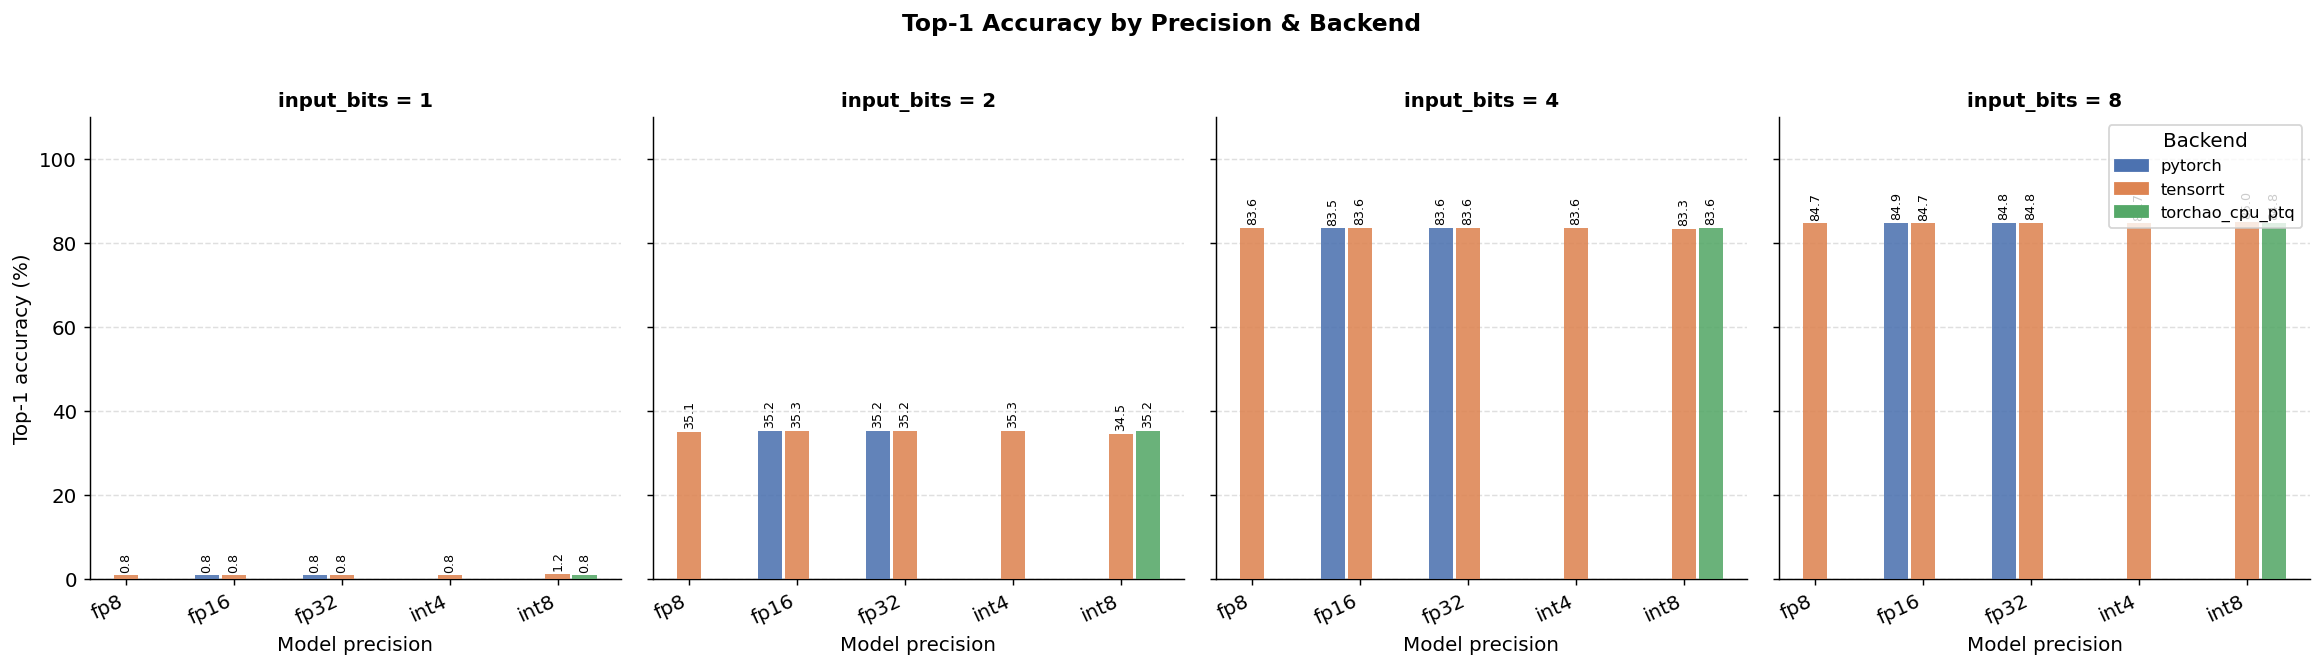

[saved] ../runs/plot1_bar_accuracy.png


In [3]:
# ── Cell 3: Grouped bar chart ────────────────────────────────────────────────
n_bits    = len(INPUT_BITS_LIST)
n_prec    = len(PRECISION_ORDER)
bar_w     = 0.75 / len(BACKENDS)

fig, axes = plt.subplots(1, n_bits, figsize=(4.5 * n_bits, 5), sharey=True)
if n_bits == 1: axes = [axes]

for ax, bits in zip(axes, INPUT_BITS_LIST):
    sub = df[df['input_bits'] == bits]
    for bi, backend in enumerate(BACKENDS):
        bdf     = sub[sub['backend'] == backend].set_index('precision')
        heights = [bdf.loc[p, 'top1'] if p in bdf.index else np.nan for p in PRECISION_ORDER]
        offsets = [i + bi*bar_w - (len(BACKENDS)-1)*bar_w/2 for i in range(n_prec)]
        bars = ax.bar(offsets, heights, width=bar_w*0.9,
                      color=bcolor(backend), label=backend, alpha=0.88, zorder=3)
        # Value labels on bars
        for rect, h in zip(bars, heights):
            if not np.isnan(h):
                ax.text(rect.get_x() + rect.get_width()/2, h + 0.8,
                        f'{h:.1f}', ha='center', va='bottom', fontsize=7, rotation=90)

    ax.set_title(f'input_bits = {bits}', fontsize=11, fontweight='bold')
    ax.set_xticks(range(n_prec))
    ax.set_xticklabels(PRECISION_ORDER, rotation=25, ha='right')
    ax.set_ylim(0, 110)
    ax.set_xlabel('Model precision')
    ax.grid(axis='y', linestyle='--', alpha=0.4, zorder=0)

axes[0].set_ylabel('Top-1 accuracy (%)')
legend_h = [mpatches.Patch(color=bcolor(b), label=b) for b in BACKENDS]
axes[-1].legend(handles=legend_h, loc='upper right', fontsize=9, title='Backend')
fig.suptitle('Top-1 Accuracy by Precision & Backend', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../runs/plot1_bar_accuracy.png', dpi=150, bbox_inches='tight')
plt.show()
print('[saved] ../runs/plot1_bar_accuracy.png')

## 🔵 Plot 2 — Scatter: Accuracy vs Latency
**Color** = backend · **Marker shape** = input_bits · **Annotations** show precision tier.

Points with different input_bits are jittered slightly on x to avoid overlap.

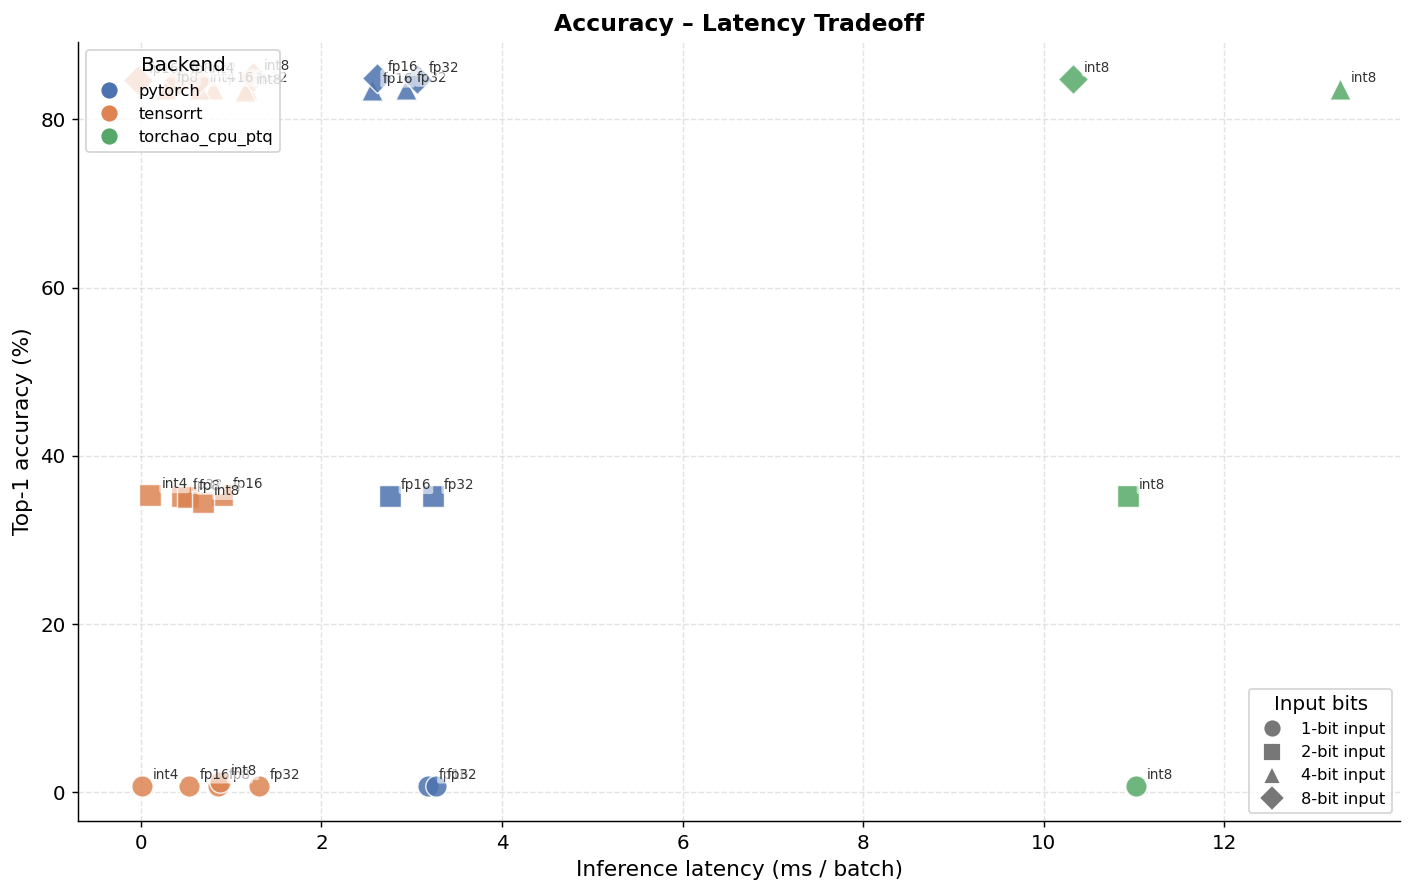

[saved] ../runs/plot2_scatter_acc_lat.png


In [4]:
# ── Cell 4: Scatter — accuracy vs latency ───────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 7))

rng   = np.random.default_rng(0)
jitter_scale = 0.04  # fraction of x-range

x_range = df['lat_ms'].max() - df['lat_ms'].min()

plotted = set()
for _, row in df.iterrows():
    if pd.isna(row['lat_ms']) or pd.isna(row['top1']):
        continue
    jx = row['lat_ms'] + rng.uniform(-jitter_scale, jitter_scale) * x_range
    marker = BITS_MARKERS.get(row['input_bits'], 'o')
    color  = bcolor(row['backend'])
    label_key = (row['backend'], row['input_bits'])

    ax.scatter(
        jx, row['top1'],
        color=color, marker=marker,
        s=140, alpha=0.85,
        edgecolors='white', linewidths=0.8, zorder=4,
    )
    # Annotation: precision label in a small bbox
    ax.annotate(
        row['precision'],
        (jx, row['top1']),
        xytext=(6, 4), textcoords='offset points',
        fontsize=7.5, color='#333',
        bbox=dict(boxstyle='round,pad=0.15', fc='white', alpha=0.6, lw=0),
        zorder=5,
    )

ax.set_xlabel('Inference latency (ms / batch)', fontsize=12)
ax.set_ylabel('Top-1 accuracy (%)', fontsize=12)
ax.set_title('Accuracy – Latency Tradeoff', fontsize=13, fontweight='bold')
ax.grid(linestyle='--', alpha=0.35)

# Legend: backend (color)
color_handles = [Line2D([0],[0], marker='o', color='w', markerfacecolor=bcolor(b),
                         markersize=10, label=b) for b in BACKENDS]
# Legend: input_bits (marker shape)
bits_handles  = [Line2D([0],[0], marker=BITS_MARKERS[b], color='w', markerfacecolor='#777',
                         markersize=10, label=f'{b}-bit input') for b in sorted(INPUT_BITS_LIST)]

leg1 = ax.legend(handles=color_handles, title='Backend',    loc='upper left',  fontsize=9)
leg2 = ax.legend(handles=bits_handles,  title='Input bits', loc='lower right', fontsize=9)
ax.add_artist(leg1)

plt.tight_layout()
plt.savefig('../runs/plot2_scatter_acc_lat.png', dpi=150, bbox_inches='tight')
plt.show()
print('[saved] ../runs/plot2_scatter_acc_lat.png')

## 📈 Plot 3 — Top-1 Accuracy vs Input Bits (line per backend×precision)
Shows how accuracy degrades as input quantization becomes more aggressive.

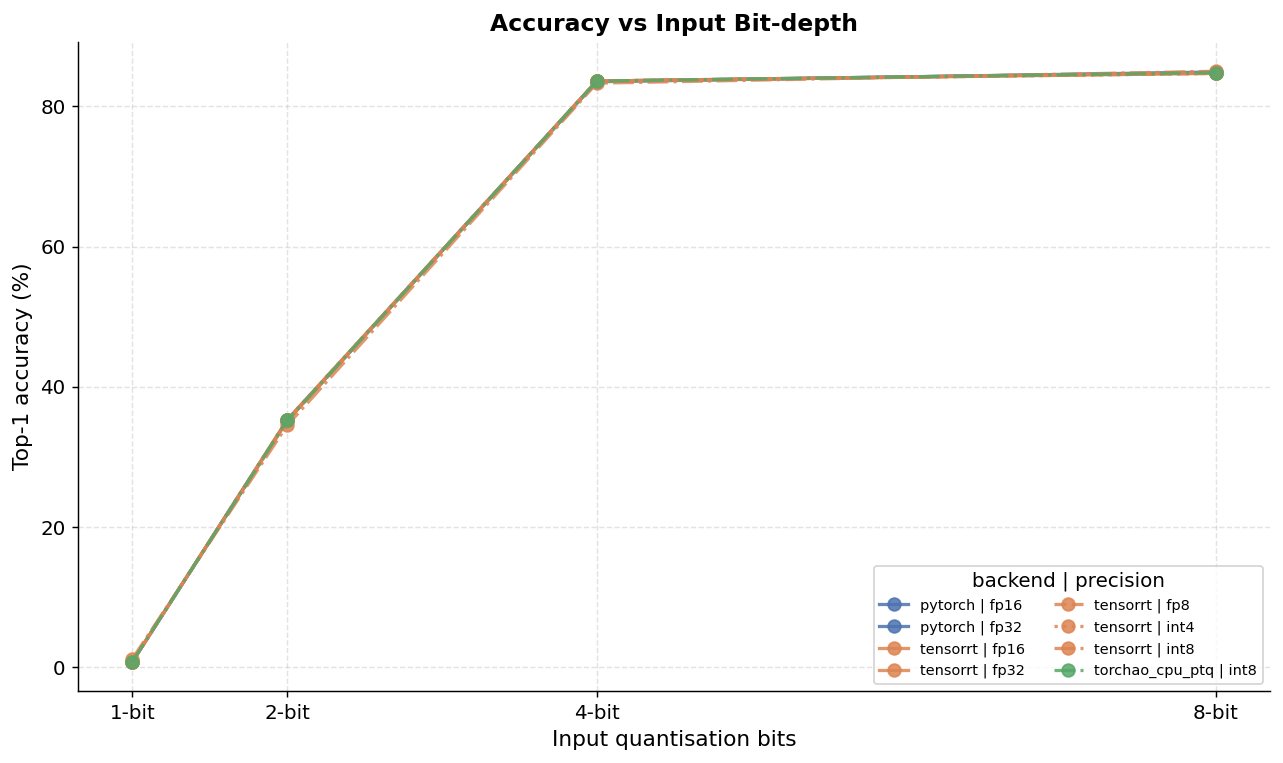

[saved] ../runs/plot3_acc_vs_bits.png


In [5]:
# ── Cell 5: Accuracy vs input_bits ──────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))

PREC_LINESTYLE = {'fp8':'--','fp16':'-','fp32':'-','int4':':','int8':'-.'}

grouped = df.groupby(['backend','precision'])
for (backend, prec), grp in grouped:
    grp_sorted = grp.sort_values('input_bits')
    xs = grp_sorted['input_bits'].values
    ys = grp_sorted['top1'].values
    ls = PREC_LINESTYLE.get(prec, '-')
    ax.plot(xs, ys, marker='o', color=bcolor(backend), linestyle=ls,
            linewidth=1.8, markersize=7, alpha=0.85,
            label=f'{backend} | {prec}')

ax.set_xlabel('Input quantisation bits', fontsize=12)
ax.set_ylabel('Top-1 accuracy (%)', fontsize=12)
ax.set_title('Accuracy vs Input Bit-depth', fontsize=13, fontweight='bold')
ax.set_xticks(INPUT_BITS_LIST)
ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%d-bit'))
ax.grid(linestyle='--', alpha=0.35)
ax.legend(fontsize=8, ncol=2, loc='lower right', title='backend | precision')

plt.tight_layout()
plt.savefig('../runs/plot3_acc_vs_bits.png', dpi=150, bbox_inches='tight')
plt.show()
print('[saved] ../runs/plot3_acc_vs_bits.png')

## ⚡ Plot 4 — Throughput Comparison
Horizontal bar chart of throughput (samples/sec) sorted descending. Color = backend.

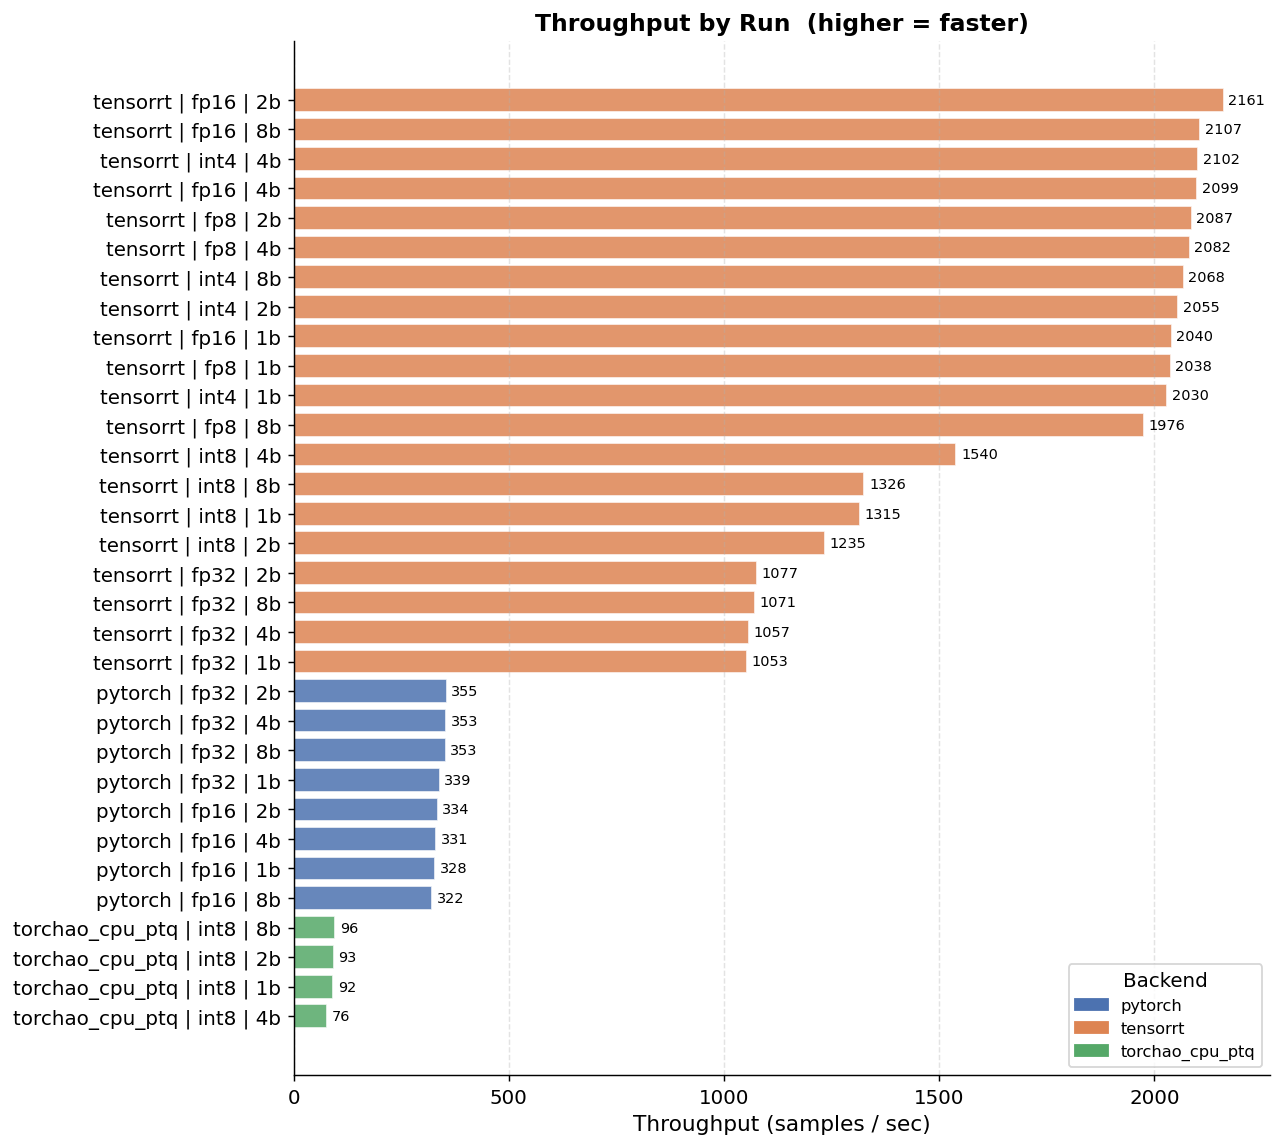

[saved] ../runs/plot4_throughput.png


In [6]:
# ── Cell 6: Throughput bar chart ─────────────────────────────────────────────
tput_df = (
    df[['backend','precision','input_bits','tput']]
    .dropna(subset=['tput'])
    .assign(label=lambda x: x['backend'] + ' | ' + x['precision'] + ' | ' + x['input_bits'].astype(str) + 'b')
    .sort_values('tput', ascending=True)
)

fig, ax = plt.subplots(figsize=(10, max(6, len(tput_df) * 0.28)))

colors = [bcolor(b) for b in tput_df['backend']]
bars   = ax.barh(tput_df['label'], tput_df['tput'], color=colors, alpha=0.85, edgecolor='white')

for bar, val in zip(bars, tput_df['tput']):
    ax.text(val + tput_df['tput'].max()*0.005, bar.get_y() + bar.get_height()/2,
            f'{val:.0f}', va='center', fontsize=8)

ax.set_xlabel('Throughput (samples / sec)', fontsize=12)
ax.set_title('Throughput by Run  (higher = faster)', fontsize=13, fontweight='bold')
ax.grid(axis='x', linestyle='--', alpha=0.35)

legend_h = [mpatches.Patch(color=bcolor(b), label=b) for b in BACKENDS]
ax.legend(handles=legend_h, loc='lower right', fontsize=9, title='Backend')

plt.tight_layout()
plt.savefig('../runs/plot4_throughput.png', dpi=150, bbox_inches='tight')
plt.show()
print('[saved] ../runs/plot4_throughput.png')